# Phase 2 — Études Statistiques
**Notebook :** `02_statistical_study.ipynb`  
**Problématique :** Comment une approche Demand-Driven s'appuyant sur l'IA peut-elle prédire la demande client réelle (Quantité + Date) pour optimiser la chaîne d'approvisionnement ?  
**Livrable :** `data/processed/dataset_ml_enrichi.parquet` + figures dans `reports/`

In [1]:
pip install requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: c:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')   # masquer les avertissements pandas/statsmodels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # formatage des axes (virgules dans les grands nombres)
import seaborn as sns                # heatmap pour la matrice de corrélation

# statsmodels : décomposition temporelle + test de Granger
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests

import holidays   # calendrier des jours fériés français

# Création des dossiers de sortie s'ils n'existent pas
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/external', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Setup OK')

Setup OK


In [3]:
# Chargement du dataset produit en Phase 1 (349 390 lignes × 24 colonnes)
df = pd.read_parquet('../data/processed/dataset_ml_final.parquet')
print(f'Shape : {df.shape}')
print(df.dtypes)

Shape : (349390, 24)
qte_demandee                      int64
prix                            float64
annee_cmd                         int32
mois_cmd                          int32
trimestre_cmd                     int32
semaine_cmd                       int64
jour_semaine_cmd                  int32
est_fin_mois_cmd                  int64
annee_liv_dem                     int32
mois_liv_dem                      int32
trimestre_liv_dem                 int32
jour_semaine_liv_dem              int32
est_weekend_liv_dem               int64
delai_demande_jours               int64
statut_enc                        int64
devise_enc                        int64
pays_enc                          int64
famille_activite_client_enc       int64
famille_activite_article_enc      int64
segment_enc                       int64
type_activite_enc                 int64
code_client_freq                  int64
code_article_freq                 int64
en_retard                       float64
dtype: object


In [4]:
# CORRECTION : on charge les VRAIES dates au jour près depuis dataset_step5.parquet
# (le ml_final.parquet n'a gardé que annee/mois/semaine, écrasant le jour exact).
#
# Pourquoi c'est critique : avec des dates forcées au 1er du mois, est_jour_ferie_cmd
# mesurait si le 1er du mois est férié (1er janvier, 1er mai...) — pas la commande.
# moyenne 0.28 = artefact, pas un vrai signal.

df_dates = pd.read_parquet('../data/processed/dataset_step5.parquet')[
    ['num_commande', 'code_article', 'date_enregistrement', 'date_livraison_demandee']
].rename(columns={
    'date_enregistrement':    'date_cmd',
    'date_livraison_demandee': 'date_liv_dem',
})

# step5 et ml_final partagent le même nombre de lignes et le même ordre
# (ml_final = step6[FEATURE_COLS + TARGET_COL], et step6 est dérivé de step5).
# On vérifie quand même la taille avant concat positionnel.
assert len(df_dates) == len(df), f'Mismatch : {len(df_dates)} vs {len(df)}'

df['date_cmd']     = df_dates['date_cmd'].values
df['date_liv_dem'] = df_dates['date_liv_dem'].values

print('Plage date_cmd    :', df['date_cmd'].min(), '→', df['date_cmd'].max())
print('Plage date_liv_dem:', df['date_liv_dem'].min(), '→', df['date_liv_dem'].max())
print('Lignes totales    :', len(df))
print('\nExemples de dates (au jour près) :')
print(df[['date_cmd', 'date_liv_dem']].head())

Plage date_cmd    : 2020-09-23 00:00:00 → 2025-12-23 00:00:00
Plage date_liv_dem: 2021-01-04 00:00:00 → 2025-12-23 00:00:00
Lignes totales    : 349390

Exemples de dates (au jour près) :
    date_cmd date_liv_dem
0 2020-09-23   2021-01-15
1 2020-10-08   2021-01-04
2 2020-10-08   2021-01-04
3 2020-10-08   2021-01-04
4 2020-10-08   2021-01-04


---
## Étude A — Saisonnalité et Cyclicité

### A.1 — Décomposition de la série temporelle globale

In [5]:
# Agrégation mensuelle pour la série temporelle globale.
# Avec les vraies dates au jour près, on utilise resample('MS') = Monthly Start
# pour sommer les quantités par mois calendaire.
serie_globale = (
    df.set_index('date_cmd')['qte_demandee']
      .resample('MS')
      .sum()
      .sort_index()
      .fillna(0)
)

print(f'Série globale : {len(serie_globale)} mois')
print(serie_globale.describe())

Série globale : 64 mois
count        64.000000
mean     124412.937500
std       41347.583631
min         300.000000
25%      104861.000000
50%      121658.500000
75%      142136.250000
max      244733.000000
Name: qte_demandee, dtype: float64


In [6]:
serie_globale.head()

date_cmd
2020-09-01       300
2020-10-01      1393
2020-11-01    120182
2020-12-01     36720
2021-01-01    178053
Freq: MS, Name: qte_demandee, dtype: int64

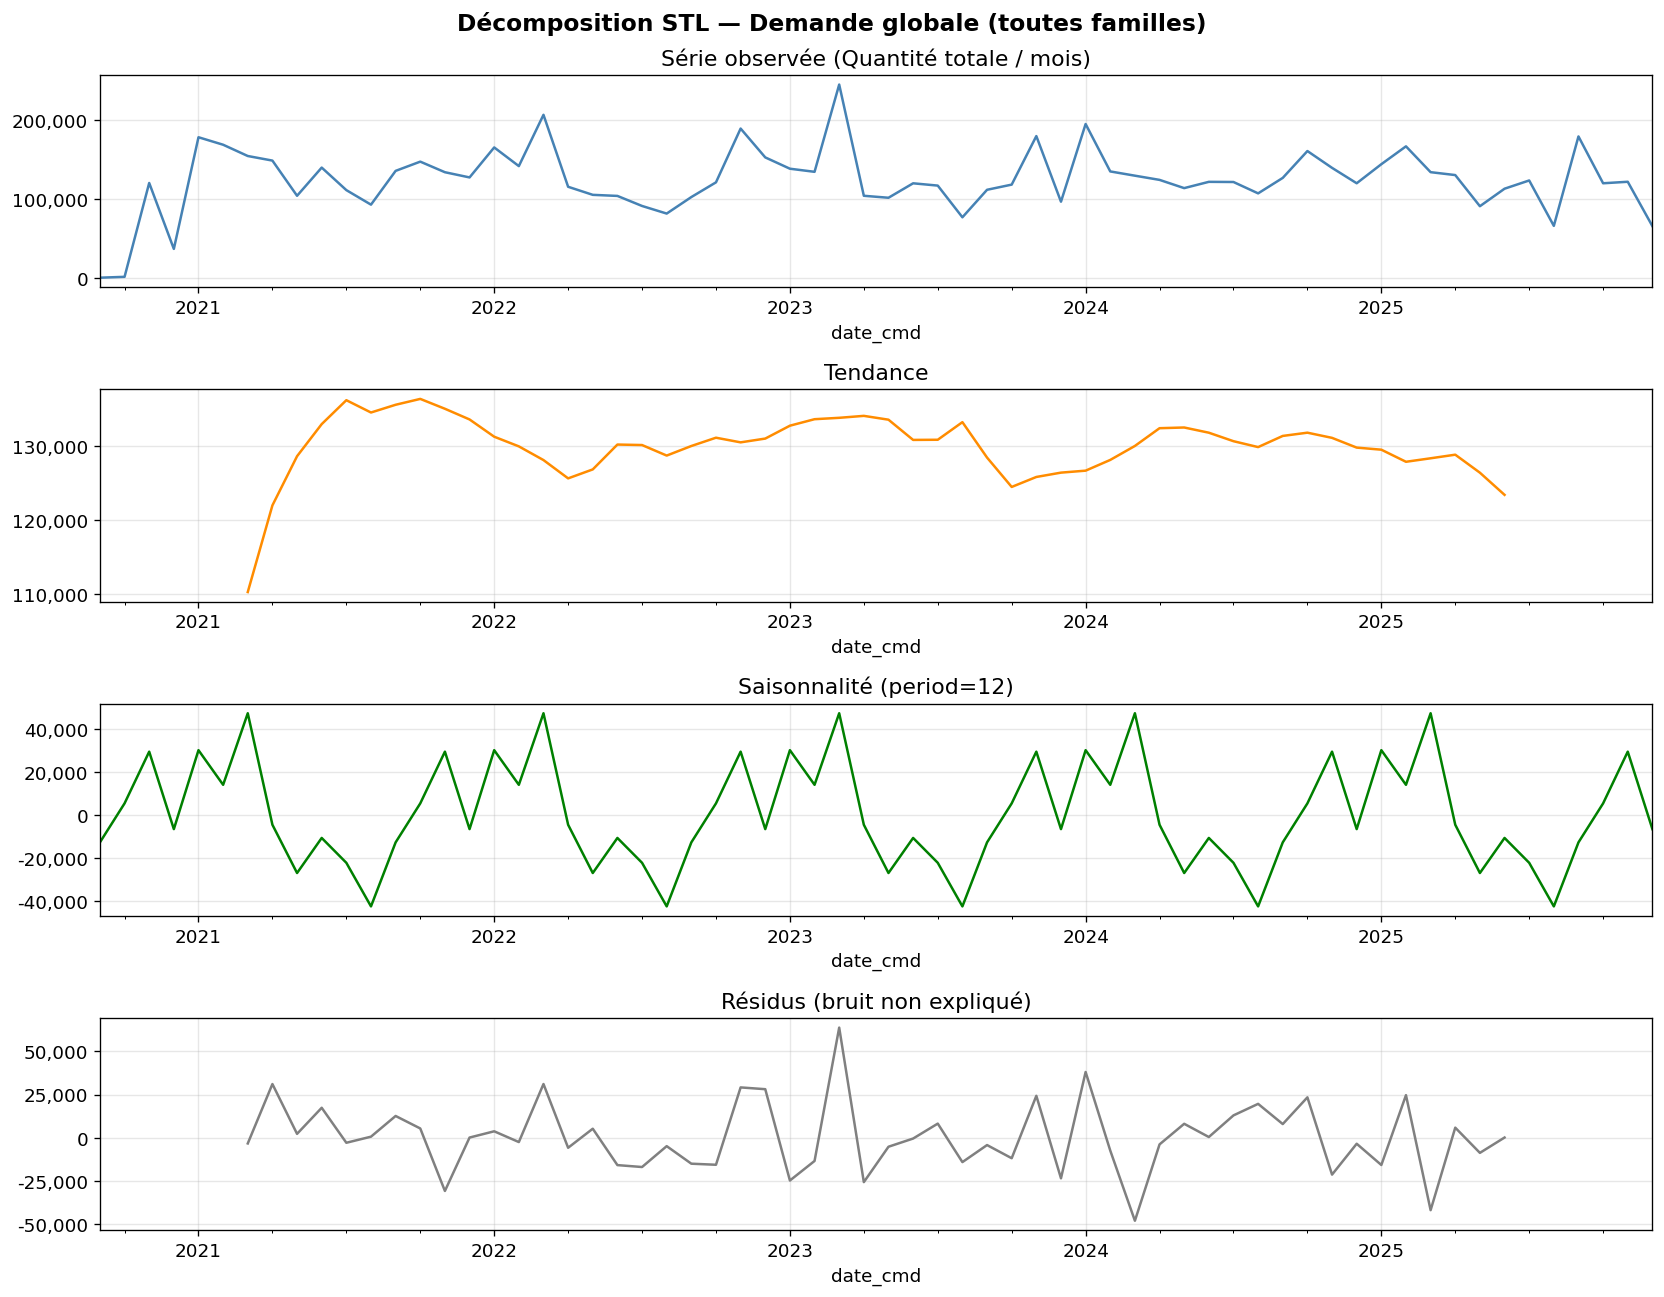

Sauvegardé → reports/decomposition_globale.png


In [7]:
# Décomposition additive : série = Tendance + Saisonnalité + Résidus
# model='additive' : les composantes s'additionnent (pas de multiplication)
# period=12 : on cherche un pattern annuel (12 mois)
decomp_global = seasonal_decompose(serie_globale, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 11))
fig.suptitle('Décomposition STL — Demande globale (toutes familles)', fontsize=14, fontweight='bold')

# 4 sous-graphes : série brute / tendance lissée / saisonnalité / résidus (bruit)
decomp_global.observed.plot(ax=axes[0], color='steelblue',  title='Série observée (Quantité totale / mois)')
decomp_global.trend.plot(   ax=axes[1], color='darkorange', title='Tendance')
decomp_global.seasonal.plot(ax=axes[2], color='green',      title='Saisonnalité (period=12)')
decomp_global.resid.plot(   ax=axes[3], color='gray',       title='Résidus (bruit non expliqué)')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/decomposition_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/decomposition_globale.png')

In [8]:
# Lecture automatique des résultats de décomposition pour le mémoire
trend_vals       = decomp_global.trend.dropna()
delta_trend      = trend_vals.iloc[-1] - trend_vals.iloc[0]      # variation totale sur toute la période
amplitude_saison = decomp_global.seasonal.max() - decomp_global.seasonal.min()  # écart pic/creux annuel

# Mois avec la demande saisonnière la plus haute / la plus basse (moyenne sur toutes les années)
mois_pic   = decomp_global.seasonal.groupby(decomp_global.seasonal.index.month).mean().idxmax()
mois_creux = decomp_global.seasonal.groupby(decomp_global.seasonal.index.month).mean().idxmin()

print('=== Interprétation Décomposition Globale ===')
print(f'Tendance  : variation totale = {delta_trend:+,.0f} unités (tendance {"haussière" if delta_trend > 0 else "baissière"})')
print(f'Saisonnalité : amplitude pic/creux = {amplitude_saison:,.0f} unités')
print(f'  → Mois pic    : mois n°{mois_pic}')
print(f'  → Mois creux  : mois n°{mois_creux}')

=== Interprétation Décomposition Globale ===
Tendance  : variation totale = +13,130 unités (tendance haussière)
Saisonnalité : amplitude pic/creux = 89,725 unités
  → Mois pic    : mois n°3
  → Mois creux  : mois n°8


### A.2 — Décomposition par famille d'article

In [9]:
familles = sorted(df['famille_activite_article_enc'].unique())
print(f'Familles présentes : {familles}')
print(df.groupby('famille_activite_article_enc')['qte_demandee'].agg(['sum','count']))

Familles présentes : [np.int64(0), np.int64(1), np.int64(2)]
                                  sum   count
famille_activite_article_enc                 
0                             7119204  338517
1                              562156    3669
2                              281068    7204


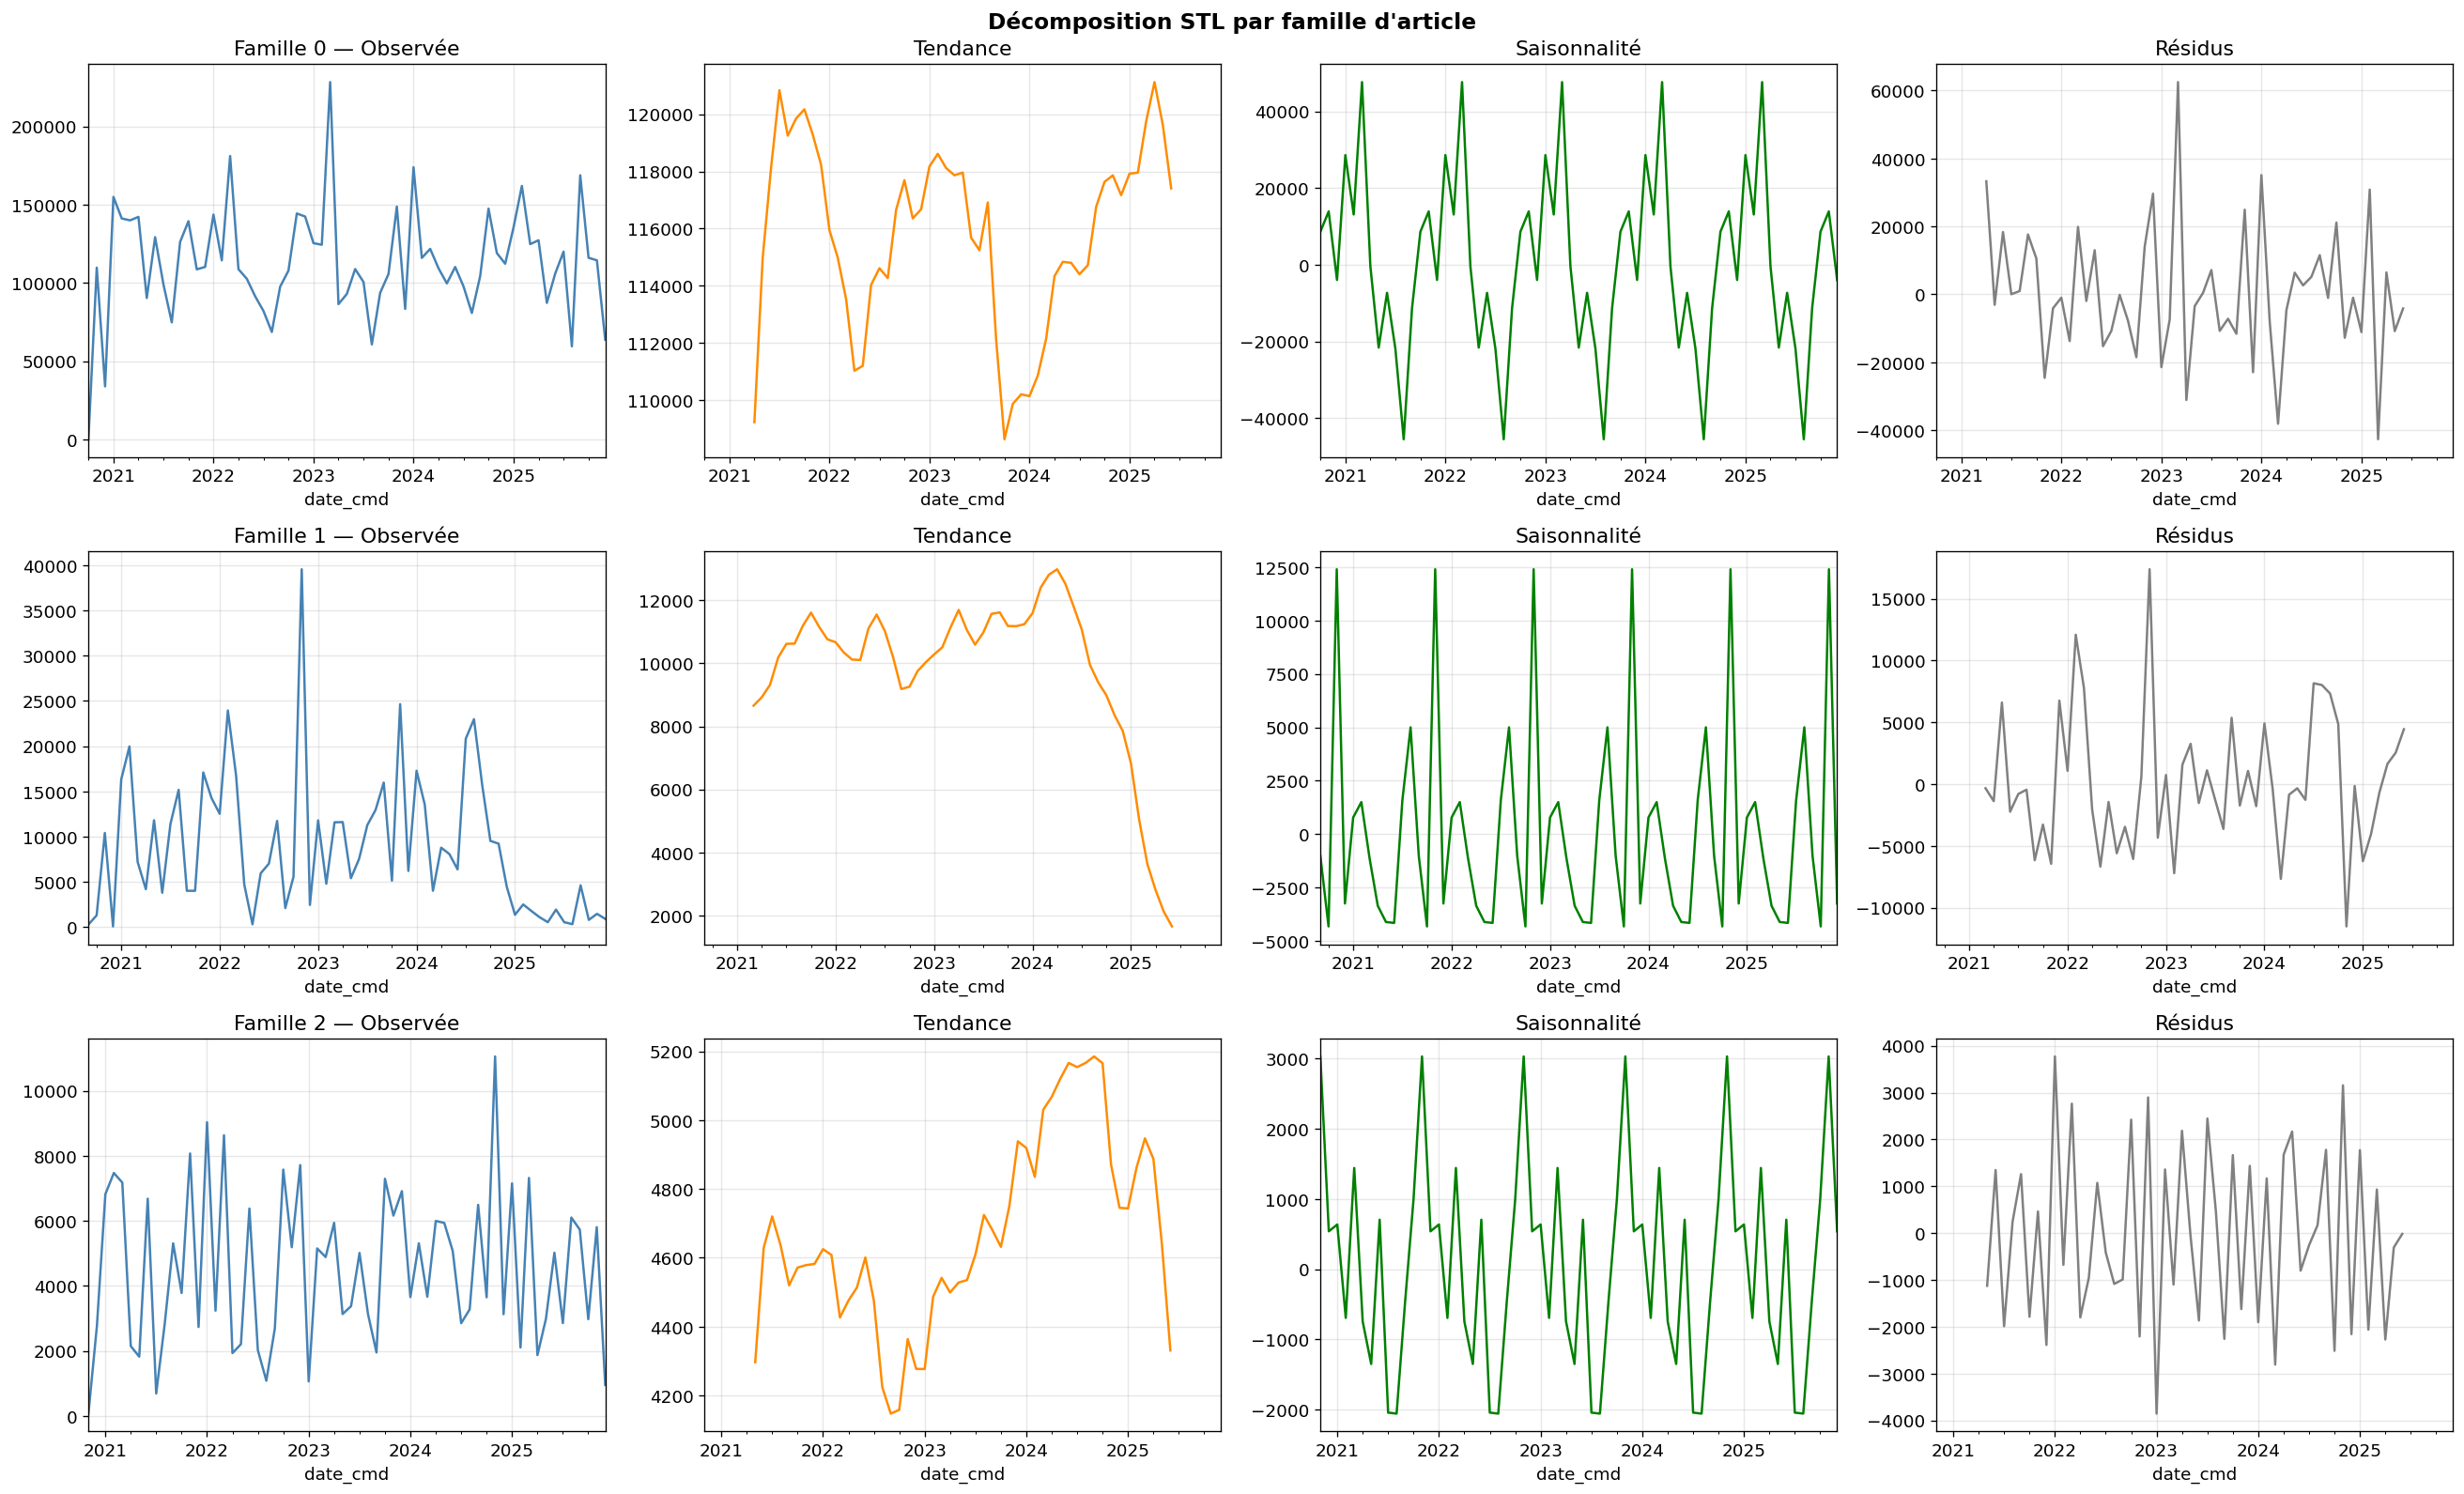

Sauvegardé → reports/decomposition_par_famille.png


In [10]:
n_familles = len(familles)
fig, axes = plt.subplots(n_familles, 4, figsize=(22, 4.5 * n_familles))
fig.suptitle('Décomposition STL par famille d\'article', fontsize=14, fontweight='bold')

for i, famille in enumerate(familles):
    subset = df[df['famille_activite_article_enc'] == famille]
    serie = (
        subset.set_index('date_cmd')['qte_demandee']
              .resample('MS')
              .sum()
              .sort_index()
              .fillna(0)
    )

    row = axes[i] if n_familles > 1 else axes

    if len(serie.dropna()) >= 24:
        decomp = seasonal_decompose(serie, model='additive', period=12)
        decomp.observed.plot( ax=row[0], title=f'Famille {famille} — Observée',   color='steelblue')
        decomp.trend.plot(    ax=row[1], title='Tendance',                        color='darkorange')
        decomp.seasonal.plot( ax=row[2], title='Saisonnalité',                    color='green')
        decomp.resid.plot(    ax=row[3], title='Résidus',                         color='gray')
        for ax in row:
            ax.grid(alpha=0.3)
    else:
        row[0].text(0.5, 0.5, f'Famille {famille}\nDonnées insuffisantes\n({len(serie)} mois)',
                   ha='center', va='center', transform=row[0].transAxes)
        for ax in row[1:]:
            ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/decomposition_par_famille.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/decomposition_par_famille.png')

### A.3 — Cycles budgétaires clients (fin de trimestre)

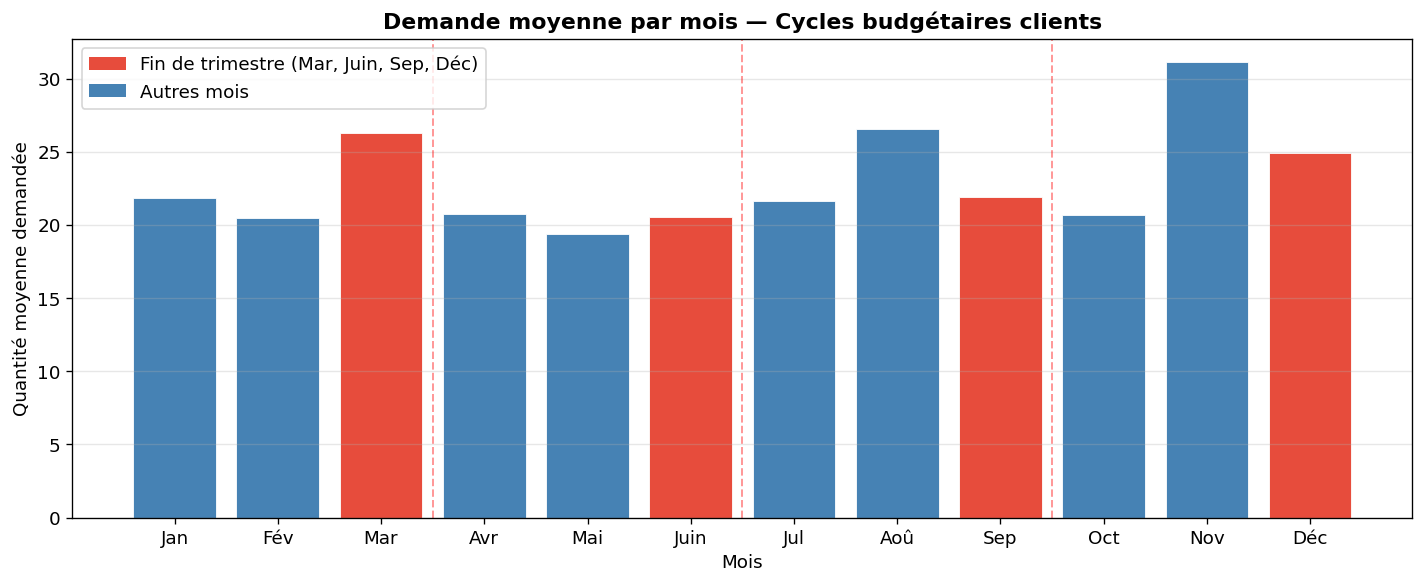

Sauvegardé → reports/cycles_budgetaires.png


In [11]:
demande_par_mois = df.groupby('mois_cmd')['qte_demandee'].mean().sort_index()

couleurs = ['#e74c3c' if m in [3, 6, 9, 12] else 'steelblue' for m in demande_par_mois.index]
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Juin','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(1, 13), demande_par_mois.values, color=couleurs, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title('Demande moyenne par mois — Cycles budgétaires clients', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Quantité moyenne demandée')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Lignes de fin de trimestre
for x in [3.5, 6.5, 9.5]:
    ax.axvline(x=x, color='red', linestyle='--', alpha=0.4, linewidth=1.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Fin de trimestre (Mar, Juin, Sep, Déc)'),
                   Patch(facecolor='steelblue', label='Autres mois')]
ax.legend(handles=legend_elements)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/cycles_budgetaires.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/cycles_budgetaires.png')

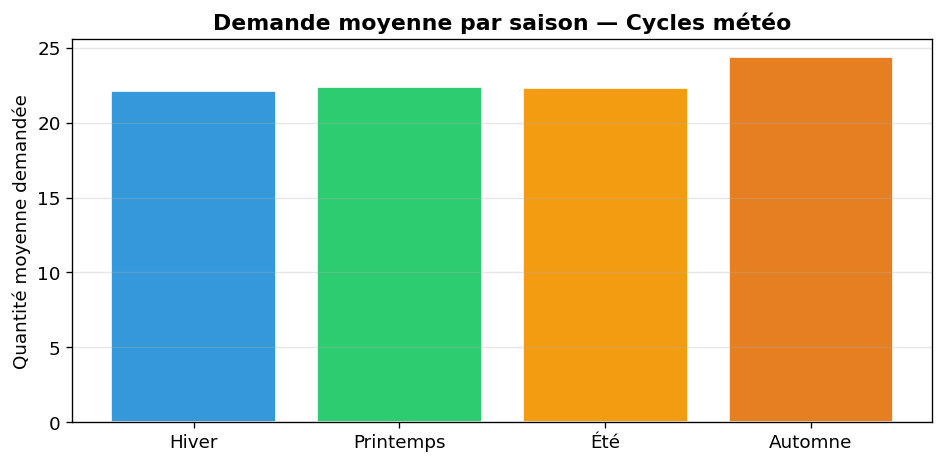


Demande moyenne par saison :
saison
Hiver        22.1
Printemps    22.4
Été          22.3
Automne      24.4
Name: qte_demandee, dtype: str


In [12]:
# Cycles météo — mois d'hiver vs été
df['saison'] = df['mois_cmd'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})

demande_saison = df.groupby('saison')['qte_demandee'].mean().reindex(['Hiver','Printemps','Été','Automne'])

fig, ax = plt.subplots(figsize=(8, 4))
couleurs_saison = ['#3498db', '#2ecc71', '#f39c12', '#e67e22']
ax.bar(demande_saison.index, demande_saison.values, color=couleurs_saison, edgecolor='white')
ax.set_title('Demande moyenne par saison — Cycles météo', fontweight='bold')
ax.set_ylabel('Quantité moyenne demandée')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cycles_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDemande moyenne par saison :')
print(demande_saison.apply(lambda x: f'{x:,.1f}'))

---
## Étude B — Corrélations Exogènes (Facteurs Externes)

### B.1.1 — Variables jours fériés (France)

In [13]:
# Calendrier des jours fériés français (2020-2025)
cal_fr = holidays.France()

# Avec les VRAIES dates au jour près, ces flags sont maintenant valides :
# ils détectent réellement si la commande / livraison demandée tombe un jour férié.
def est_ferie_fr(date):
    return int(date in cal_fr)

df['est_jour_ferie_cmd']     = df['date_cmd'].apply(est_ferie_fr)
df['est_jour_ferie_liv_dem'] = df['date_liv_dem'].apply(est_ferie_fr)

# NOTE : on NE crée PAS nb_jours_feries_dans_delai ni nb_weekends_dans_delai.
# Raison : ces compteurs sont fonctionnellement quasi-linéaires de delai_demande_jours
# (≈ délai/7 pour les week-ends, ≈ délai/30 pour les fériés). Les inclure injecterait
# une redondance trompeuse qui apparaîtrait comme une fausse corrélation forte avec
# la cible alors qu'on mesure surtout le délai — déjà présent comme feature.

print('Variables jours fériés créées (vraies dates) :')
print(df[['est_jour_ferie_cmd', 'est_jour_ferie_liv_dem']].describe())
print(f"\nFréquence : {df['est_jour_ferie_cmd'].mean()*100:.2f}% des commandes un jour férié")
print(f"            {df['est_jour_ferie_liv_dem'].mean()*100:.2f}% des livraisons demandées un jour férié")

Variables jours fériés créées (vraies dates) :
       est_jour_ferie_cmd  est_jour_ferie_liv_dem
count       349390.000000           349390.000000
mean             0.000155                0.000323
std              0.012431                0.017981
min              0.000000                0.000000
25%              0.000000                0.000000
50%              0.000000                0.000000
75%              0.000000                0.000000
max              1.000000                1.000000

Fréquence : 0.02% des commandes un jour férié
            0.03% des livraisons demandées un jour férié


### B.1.2 — Variables météo (Open-Meteo — proxy Paris)

In [14]:
import urllib.request
import urllib.parse
import json

# Open-Meteo Archive API : on récupère en DAILY puis on agrège en mensuel
# Paris comme proxy France (89% des commandes GE)
params = {
    'latitude':   '48.85',
    'longitude':  '2.35',
    'start_date': '2020-01-01',
    'end_date':   '2025-12-31',
    'daily':      ['precipitation_sum', 'wind_speed_10m_max', 'temperature_2m_min'],
    'timezone':   'Europe/Paris',
}
url = 'https://archive-api.open-meteo.com/v1/archive?' + urllib.parse.urlencode(params, doseq=True)

with urllib.request.urlopen(url, timeout=30) as resp:
    data = json.loads(resp.read().decode())

# Construction du DataFrame daily
daily = data['daily']
meteo_daily = pd.DataFrame({
    'date':             pd.to_datetime(daily['time']),
    'pluie_mm':         daily['precipitation_sum'],
    'vent_max_kmh':     daily['wind_speed_10m_max'],
    'temp_min_celsius': daily['temperature_2m_min'],
})

# Agrégation mensuelle : somme pour la pluie, max pour le vent, min pour la temp
meteo_fr = (
    meteo_daily
    .set_index('date')
    .resample('MS')   # MS = début de mois
    .agg({
        'pluie_mm':         'sum',
        'vent_max_kmh':     'max',
        'temp_min_celsius': 'min',
    })
    .rename(columns={'pluie_mm': 'pluie_mm_mois'})
    .reset_index()
)

print('Météo mensuelle récupérée :')
print(meteo_fr.head())
print(f'\n{len(meteo_fr)} mois de données météo')

Météo mensuelle récupérée :
        date  pluie_mm_mois  vent_max_kmh  temp_min_celsius
0 2020-01-01           29.4          36.7              -3.2
1 2020-02-01          103.7          49.1              -1.3
2 2020-03-01           67.7          42.3              -0.6
3 2020-04-01           30.4          35.1              -0.9
4 2020-05-01           37.3          36.5               4.3

72 mois de données météo


In [15]:
# Jointure météo sur le mois de livraison demandée.
# On convertit les deux dates en "1er du mois" pour faire coïncider les clés de jointure.
df['mois_liv_dem_dt'] = df['date_liv_dem'].dt.to_period('M').dt.to_timestamp()
meteo_fr['date']      = meteo_fr['date'].dt.to_period('M').dt.to_timestamp()

# LEFT JOIN : toutes les lignes du dataset sont conservées
# Si une date de livraison est hors plage météo → NaN (on vérifie en dessous)
df = df.merge(
    meteo_fr.rename(columns={
        'pluie_mm_mois':    'pluie_mm_liv_dem',
        'vent_max_kmh':     'vent_max_kmh_liv_dem',
        'temp_min_celsius': 'temp_min_liv_dem'
    }),
    left_on='mois_liv_dem_dt', right_on='date', how='left'
).drop(columns=['date'])  # supprime la colonne 'date' dupliquée après fusion

print('NaN météo :', df[['pluie_mm_liv_dem','vent_max_kmh_liv_dem','temp_min_liv_dem']].isna().sum().to_dict())

NaN météo : {'pluie_mm_liv_dem': 0, 'vent_max_kmh_liv_dem': 0, 'temp_min_liv_dem': 0}


### B.1.3 — Indice de Production Industrielle France (INSEE)

In [16]:
# Chargement IPI depuis les fichiers INSEE téléchargés (NACE 41 — Construction de bâtiments, base 100=2021)
# Fichier valeurs_mensuelles.csv : 4 lignes d'en-tête INSEE, puis YYYY-MM ; valeur ; code
IPI_VALUES  = '../data/external/valeurs_mensuelles.csv'
IPI_LEGACY  = '../data/external/ipi_france.csv'

def charger_ipi_insee(path):
    """Parse le format INSEE standard : 4 lignes de méta, puis YYYY-MM;valeur;code."""
    raw = pd.read_csv(path, sep=';', header=None, skiprows=4, dtype=str)
    raw = raw[[0, 1]].copy()
    raw.columns = ['periode', 'ipi_valeur']
    # Garder uniquement les lignes dont la période est au format YYYY-MM
    raw = raw[raw['periode'].str.match(r'^\d{4}-\d{2}$', na=False)].copy()
    raw['date']      = pd.to_datetime(raw['periode'] + '-01')
    raw['ipi_valeur'] = pd.to_numeric(raw['ipi_valeur'], errors='coerce')
    return raw[['date', 'ipi_valeur']].dropna().sort_values('date').reset_index(drop=True)

if os.path.exists(IPI_VALUES):
    ipi = charger_ipi_insee(IPI_VALUES)
    print(f'IPI chargé depuis {IPI_VALUES}  ({len(ipi)} mois, NACE 41 Construction, base 2021)')
elif os.path.exists(IPI_LEGACY):
    ipi = pd.read_csv(IPI_LEGACY, parse_dates=['date'])
    ipi['date'] = ipi['date'].dt.to_period('M').dt.to_timestamp()
    print(f'IPI chargé depuis {IPI_LEGACY} ({len(ipi)} mois)')
else:
    # Fallback hardcodé — NACE 41 Construction de bâtiments, base 100=2021 (source INSEE)
    ipi_dict = {
        '2020-01': 111.32, '2020-02': 115.04, '2020-03':  76.64, '2020-04':  39.34,
        '2020-05':  85.15, '2020-06': 109.41, '2020-07': 113.09, '2020-08':  75.67,
        '2020-09': 109.83, '2020-10': 112.86, '2020-11': 111.05, '2020-12':  91.55,
        '2021-01': 100.70, '2021-02': 102.78, '2021-03': 109.56, '2021-04': 103.72,
        '2021-05': 103.65, '2021-06': 109.42, '2021-07': 104.64, '2021-08':  64.38,
        '2021-09': 103.38, '2021-10': 106.62, '2021-11': 105.83, '2021-12':  85.33,
        '2022-01':  95.02, '2022-02': 100.31, '2022-03': 105.84, '2022-04':  98.51,
        '2022-05': 102.91, '2022-06': 103.71, '2022-07':  98.21, '2022-08':  64.25,
        '2022-09': 101.54, '2022-10': 104.60, '2022-11': 106.10, '2022-12':  84.32,
        '2023-01':  95.35, '2023-02': 101.54, '2023-03': 106.61, '2023-04': 100.13,
        '2023-05': 104.67, '2023-06': 107.76, '2023-07': 101.69, '2023-08':  63.08,
        '2023-09':  99.76, '2023-10': 104.25, '2023-11': 102.27, '2023-12':  79.75,
        '2024-01':  92.64, '2024-02':  97.14, '2024-03':  97.27, '2024-04':  94.09,
        '2024-05':  94.78, '2024-06':  98.24, '2024-07':  95.25, '2024-08':  55.64,
        '2024-09':  91.22, '2024-10':  96.50, '2024-11':  95.30, '2024-12':  77.28,
        '2025-01':  84.17, '2025-02':  88.94, '2025-03':  90.50, '2025-04':  89.30,
        '2025-05':  88.96, '2025-06':  91.20, '2025-07':  91.90, '2025-08':  54.06,
        '2025-09':  88.61, '2025-10':  93.01, '2025-11':  88.42, '2025-12':  75.10,
    }
    ipi = pd.DataFrame([
        {'date': pd.to_datetime(k + '-01'), 'ipi_valeur': v}
        for k, v in ipi_dict.items()
    ])
    print('AVERTISSEMENT : fichiers INSEE non trouvés — valeurs hardcodées NACE 41 utilisées.')

print(ipi.head())
print(f'Plage : {ipi["date"].min().date()} → {ipi["date"].max().date()}')

# Jointure sur le mois de commande
df['mois_cmd_dt'] = df['date_cmd'].dt.to_period('M').dt.to_timestamp()
df = df.merge(
    ipi.rename(columns={'date': 'mois_cmd_dt'}),
    on='mois_cmd_dt', how='left'
)

print(f"\nNaN IPI : {df['ipi_valeur'].isna().sum()}")
print(df['ipi_valeur'].describe())

IPI chargé depuis ../data/external/valeurs_mensuelles.csv  (75 mois, NACE 41 Construction, base 2021)
        date  ipi_valeur
0 2020-01-01      111.32
1 2020-02-01      115.04
2 2020-03-01       76.64
3 2020-04-01       39.34
4 2020-05-01       85.15
Plage : 2020-01-01 → 2026-03-01



NaN IPI : 0


count    349390.000000
mean         95.872387
std          10.778314
min          54.060000
25%          91.200000
50%          98.210000
75%         103.650000
max         112.860000
Name: ipi_valeur, dtype: float64


### B.1.4 — ~~Taux de change~~ (retiré : variance quasi nulle)

Le mapping `devise_enc → devise` montre que **99.7 % des commandes sont en EUR** (348 312 / 349 390).  
Conséquence : la feature `taux_change_devise` est quasi-constante (1.0 partout sauf 1 078 lignes), donc :
- variance ≈ 0 → corrélation de Pearson non interprétable
- aucune information prédictive utile pour le modèle

→ **Feature retirée** du dataset enrichi.

### B.1.5 — Variables contextuelles (vacances, peak, COVID)

In [17]:
# Vacances scolaires France (toutes zones A, B, C)
vacances_fr = [
    ('2021-02-06','2021-03-07'), ('2021-04-10','2021-04-25'),
    ('2021-07-07','2021-08-31'), ('2021-10-23','2021-11-07'), ('2021-12-18','2022-01-02'),
    ('2022-02-05','2022-03-06'), ('2022-04-09','2022-04-24'),
    ('2022-07-07','2022-08-31'), ('2022-10-22','2022-11-06'), ('2022-12-17','2023-01-02'),
    ('2023-02-04','2023-03-05'), ('2023-04-08','2023-04-23'),
    ('2023-07-08','2023-08-31'), ('2023-10-21','2023-11-05'), ('2023-12-23','2024-01-07'),
    ('2024-02-10','2024-03-10'), ('2024-04-06','2024-04-21'),
    ('2024-07-06','2024-08-31'), ('2024-10-19','2024-11-03'), ('2024-12-21','2025-01-05'),
    ('2025-02-08','2025-03-09'), ('2025-04-05','2025-04-20'),
    ('2025-07-05','2025-08-31'), ('2025-10-18','2025-11-02'), ('2025-12-20','2026-01-04'),
]
vacances_intervals = [(pd.Timestamp(d), pd.Timestamp(f)) for d, f in vacances_fr]

covid_intervals = [
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30')),
    (pd.Timestamp('2022-01-01'), pd.Timestamp('2022-03-31')),
]

def est_vacances(date):
    return int(any(d <= date <= f for d, f in vacances_intervals))

def est_covid(date):
    return int(any(d <= date <= f for d, f in covid_intervals))

# Périodes de forte demande : rentrée (sep), Black Friday / Noël (nov, déc)
df['est_vacances_scolaires_liv_dem'] = df['date_liv_dem'].apply(est_vacances)
df['est_periode_peak_liv_dem']       = df['mois_liv_dem'].isin([9, 11, 12]).astype(int)
df['est_periode_covid']              = df['date_cmd'].apply(est_covid)

print('Variables contextuelles créées :')
for col in ['est_vacances_scolaires_liv_dem','est_periode_peak_liv_dem','est_periode_covid']:
    print(f'  {col}: {df[col].value_counts().to_dict()}')

Variables contextuelles créées :
  est_vacances_scolaires_liv_dem: {0: 246575, 1: 102815}
  est_periode_peak_liv_dem: {0: 272726, 1: 76664}
  est_periode_covid: {0: 286086, 1: 63304}


### B.2 — Matrice de corrélation de Pearson

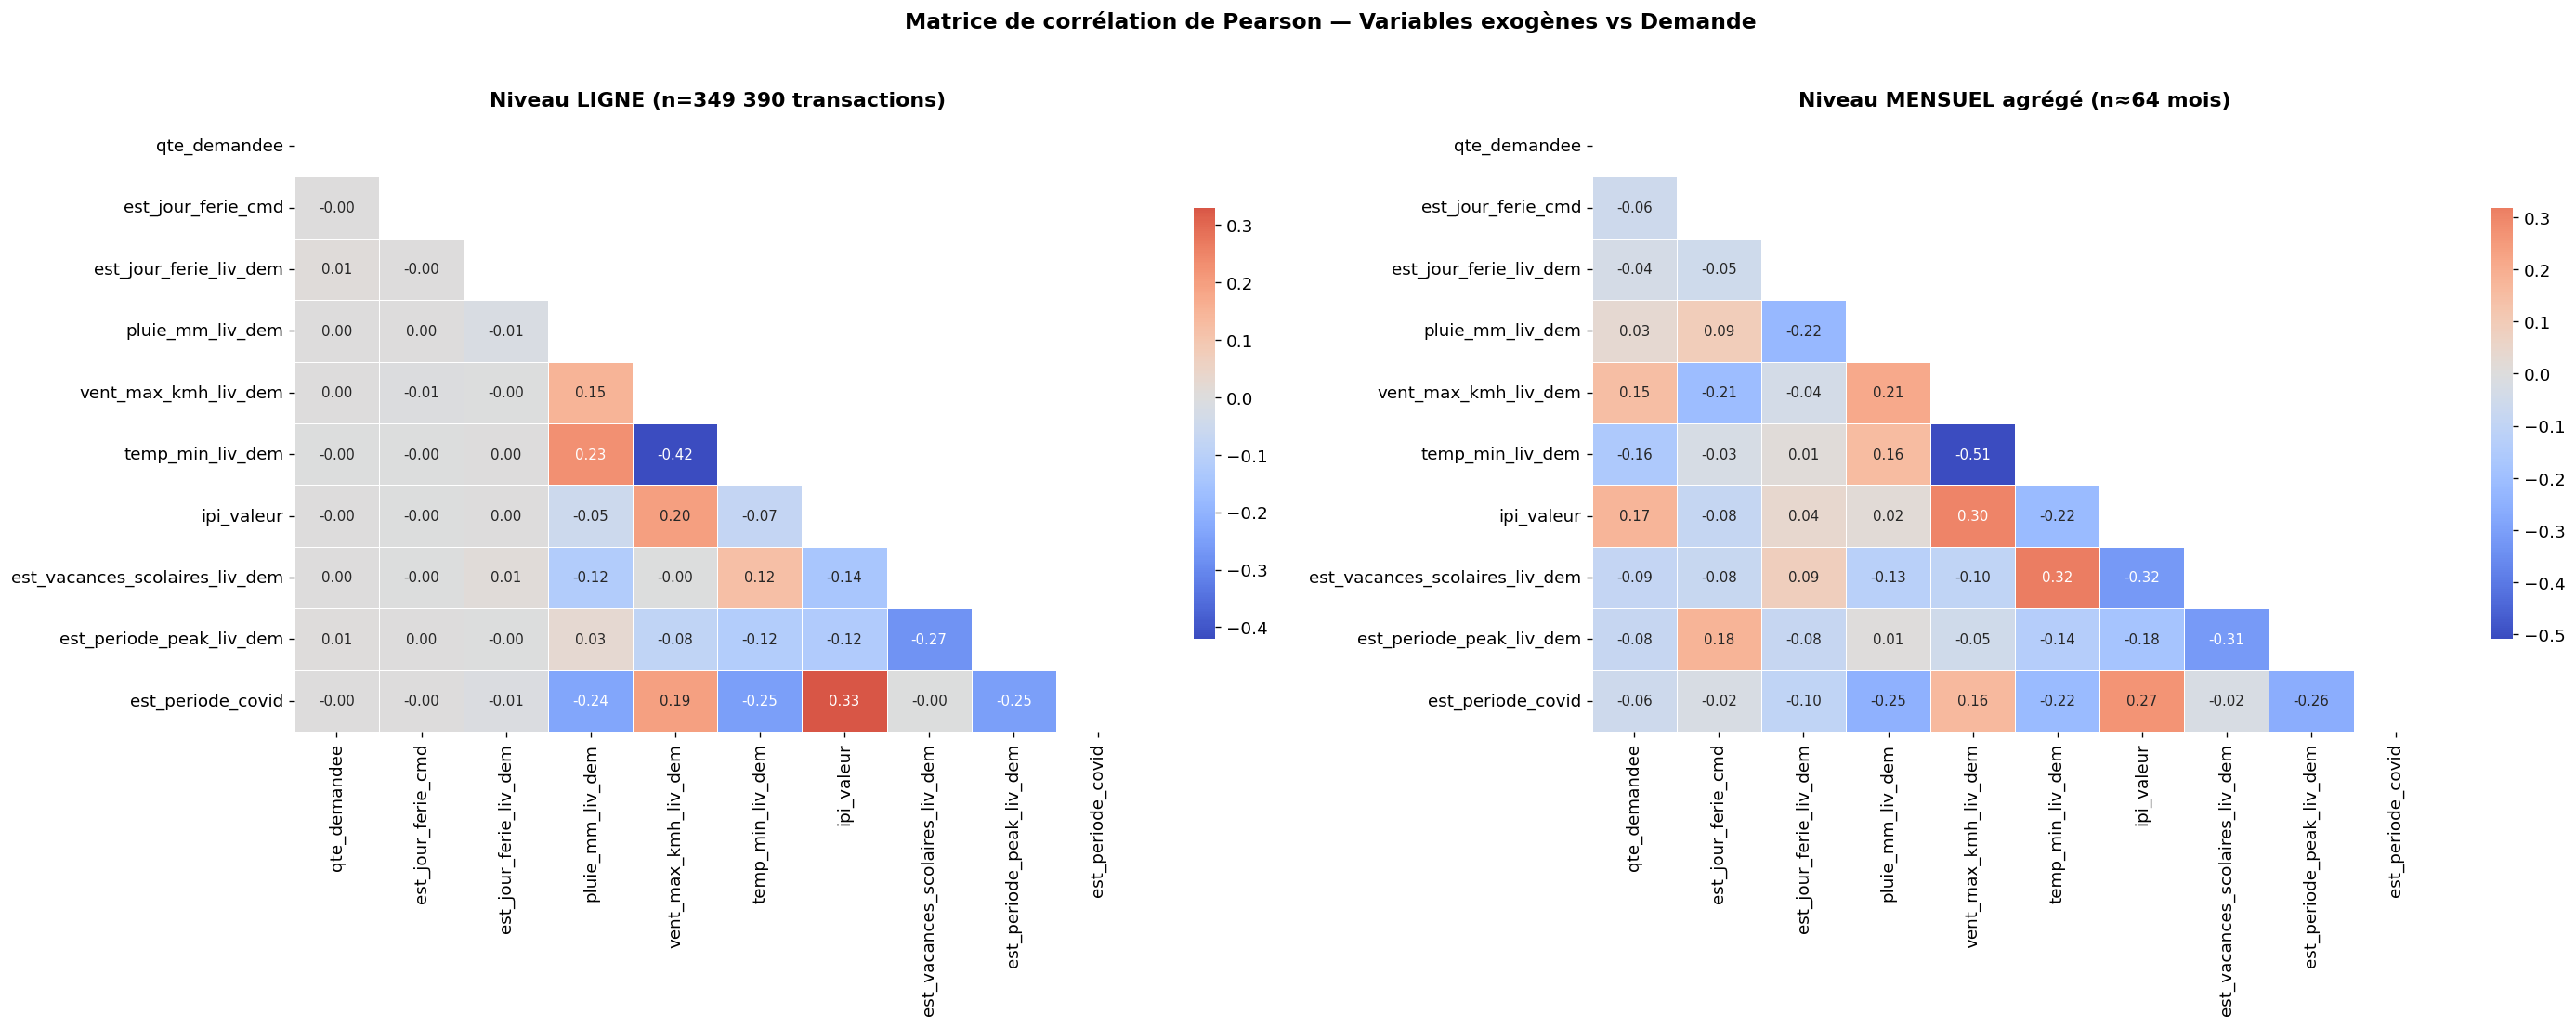

Sauvegardé → reports/matrice_correlation_pearson.png


In [18]:
# Variables à analyser : cible + facteurs externes nettoyés
# Retirés vs version précédente :
#   - nb_jours_feries_dans_delai, nb_weekends_dans_delai (artefacts collinéaires avec délai)
#   - taux_change_devise (99.7% EUR → variance ≈ 0)
vars_exogenes = [
    'qte_demandee',                       # variable cible
    'est_jour_ferie_cmd',                 # commande passée un jour férié ? (vraie date)
    'est_jour_ferie_liv_dem',             # livraison demandée un jour férié ? (vraie date)
    'pluie_mm_liv_dem',                   # pluie au mois de livraison
    'vent_max_kmh_liv_dem',               # vent max au mois de livraison
    'temp_min_liv_dem',                   # température min au mois de livraison
    'ipi_valeur',                         # indice de production industrielle France
    'est_vacances_scolaires_liv_dem',     # livraison pendant vacances scolaires ?
    'est_periode_peak_liv_dem',           # livraison en période de forte demande (sep/nov/déc) ?
    'est_periode_covid',                  # commande passée pendant perturbation COVID ?
]

# === Corrélation au niveau LIGNE (sur les 349 390 transactions) ===
# Plus représentative du signal qu'un modèle ligne-à-ligne va apprendre.
corr_ligne = df[vars_exogenes].corr(method='pearson')

# === Corrélation au niveau MENSUEL AGRÉGÉ (sur ~64 mois) ===
# Vue macro qui révèle les co-mouvements temporels, utile pour Granger.
# .mean() sur les binaires donne la proportion mensuelle (variance retrouvée).
df_mensuel = (
    df.set_index('date_cmd')[vars_exogenes]
      .resample('MS')
      .mean()
)
corr_mensuel = df_mensuel.corr(method='pearson')

# Heatmap côte-à-côte : ligne vs mensuel
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

for ax, corr, titre in [
    (axes[0], corr_ligne,   'Niveau LIGNE (n=349 390 transactions)'),
    (axes[1], corr_mensuel, 'Niveau MENSUEL agrégé (n≈64 mois)'),
]:
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, linewidths=0.5, ax=ax, mask=mask,
        annot_kws={'size': 9}, cbar_kws={'shrink': 0.7}
    )
    ax.set_title(titre, fontweight='bold')

fig.suptitle('Matrice de corrélation de Pearson — Variables exogènes vs Demande',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/matrice_correlation_pearson.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/matrice_correlation_pearson.png')

In [19]:
# Comparaison des corrélations LIGNE vs MENSUEL avec la cible
corr_ligne_vs_cible = (
    corr_ligne['qte_demandee'].drop('qte_demandee')
    .sort_values(key=abs, ascending=False)
)
corr_mensuel_vs_cible = corr_mensuel['qte_demandee'].drop('qte_demandee')

# Table comparative
tab = pd.DataFrame({
    'r_ligne':   corr_ligne_vs_cible,
    'r_mensuel': corr_mensuel_vs_cible.reindex(corr_ligne_vs_cible.index),
})
tab['|r_max|']      = tab[['r_ligne','r_mensuel']].abs().max(axis=1)
tab['significatif'] = tab['|r_max|'] > 0.15

print('=== Pearson : niveau LIGNE vs MENSUEL ===')
print(tab.round(3).to_string())

# Variables retenues pour Granger : significatives sur AU MOINS un des deux niveaux
vars_sig = tab[tab['significatif']].index.tolist()
print(f'\nSeuil |r| > 0.15 sur ligne OU mensuel : {len(vars_sig)} variable(s) → {vars_sig}')

=== Pearson : niveau LIGNE vs MENSUEL ===
                                r_ligne  r_mensuel  |r_max|  significatif
est_jour_ferie_liv_dem            0.008     -0.035    0.035         False
est_periode_peak_liv_dem          0.006     -0.080    0.080         False
temp_min_liv_dem                 -0.004     -0.156    0.156          True
est_vacances_scolaires_liv_dem    0.002     -0.089    0.089         False
vent_max_kmh_liv_dem              0.002      0.149    0.149         False
est_periode_covid                -0.001     -0.058    0.058         False
est_jour_ferie_cmd               -0.001     -0.058    0.058         False
ipi_valeur                       -0.001      0.174    0.174          True
pluie_mm_liv_dem                  0.000      0.033    0.033         False

Seuil |r| > 0.15 sur ligne OU mensuel : 2 variable(s) → ['temp_min_liv_dem', 'ipi_valeur']


### B.3 — Test de causalité de Granger

In [20]:
# Test de Granger sur les variables significatives (|r| > 0.15 sur ligne OU mensuel)
# Principe : "X cause-t-il Y au sens de Granger ?"
# On vérifie si les valeurs passées de X améliorent la prédiction de Y,
# au-delà de ce que les valeurs passées de Y seules permettent.
# p < 0.05 → X apporte une information prédictive sur Y.
# maxlag=3 : on teste avec 1, 2 et 3 mois de décalage.
#
# IMPORTANT : Granger se fait sur la série MENSUELLE (~64 mois). Avec ce
# faible n, la puissance statistique est limitée — interpréter avec prudence.

variables_a_tester = vars_sig
print(f'Variables testées avec Granger : {variables_a_tester}')

resultats_granger = {}

for var in variables_a_tester:
    data = df_mensuel[['qte_demandee', var]].dropna()
    if len(data) < 10 or data[var].nunique() < 2:
        resultats_granger[var] = {'lag_1': np.nan, 'lag_2': np.nan, 'lag_3': np.nan}
        continue
    try:
        res = grangercausalitytests(data, maxlag=3, verbose=False)
        p_values = [res[lag][0]['ssr_ftest'][1] for lag in [1, 2, 3]]
        resultats_granger[var] = {f'lag_{lag}': round(p, 4) for lag, p in zip([1, 2, 3], p_values)}
    except Exception as e:
        resultats_granger[var] = {'erreur': str(e)}

df_granger = pd.DataFrame(resultats_granger).T
print('\n=== Résultats Test de Granger (p-values) ===')
print('  p < 0.05 → la variable « cause Granger » la demande GE')
print(df_granger.to_string())

Variables testées avec Granger : ['temp_min_liv_dem', 'ipi_valeur']

=== Résultats Test de Granger (p-values) ===
  p < 0.05 → la variable « cause Granger » la demande GE
                   lag_1   lag_2  lag_3
temp_min_liv_dem  0.2830  0.6085  0.572
ipi_valeur        0.1583  0.2646  0.021


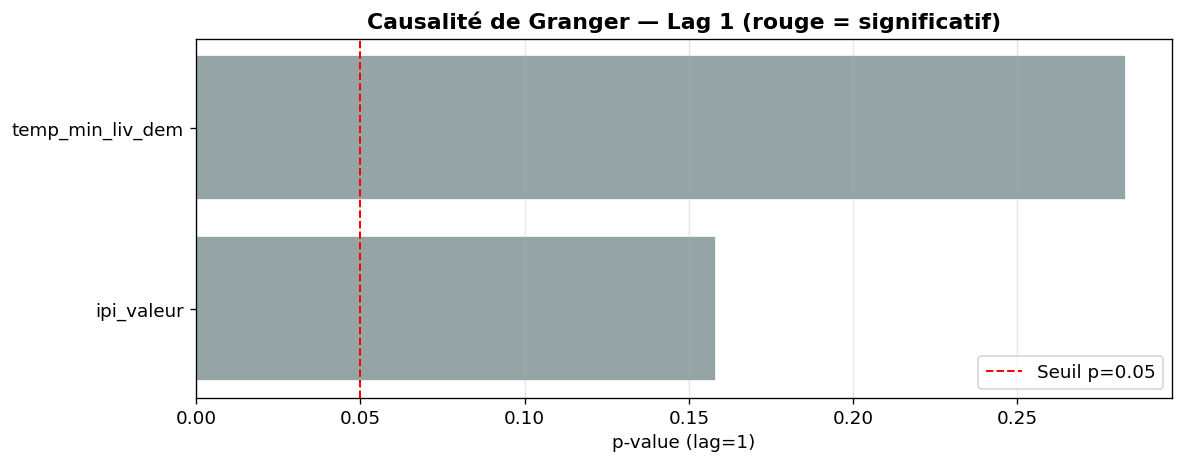

Sauvegardé → reports/granger_pvalues.png


In [21]:
# Visualisation des p-values Granger
if not df_granger.empty and 'lag_1' in df_granger.columns:
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_granger) * 0.6)))

    p_lag1 = pd.to_numeric(df_granger['lag_1'], errors='coerce').dropna().sort_values()
    couleurs_g = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in p_lag1.values]

    ax.barh(p_lag1.index, p_lag1.values, color=couleurs_g, edgecolor='white')
    ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1.2, label='Seuil p=0.05')
    ax.set_xlabel('p-value (lag=1)')
    ax.set_title('Causalité de Granger — Lag 1 (rouge = significatif)', fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/granger_pvalues.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegardé → reports/granger_pvalues.png')

### B.4 — Rapport d'impact des facteurs externes

In [22]:
print('=' * 70)
print('RAPPORT D\'IMPACT DES FACTEURS EXTERNES — Phase 2 (corrigé)')
print('=' * 70)

print('\n1. Corrélation Pearson avec qte_demandee (ligne vs mensuel) :')
print(tab.round(3).to_string())

print('\n2. Causalité de Granger (p-values, série mensuelle) :')
if not df_granger.empty:
    print(df_granger.to_string())
    causal_vars = []
    if 'lag_1' in df_granger.columns:
        causal_vars = df_granger[
            pd.to_numeric(df_granger['lag_1'], errors='coerce') < 0.05
        ].index.tolist()
    print(f'\n   Variables causant Granger (p<0.05, lag=1) : {causal_vars}')

print('\n3. Synthèse :')
print('   → Features retirées du dataset enrichi :')
print('     • nb_jours_feries_dans_delai, nb_weekends_dans_delai (artefacts collinéaires')
print('       avec delai_demande_jours, déjà présent comme feature)')
print('     • taux_change_devise (99.7% EUR → variance ≈ 0)')
print('   → Features retenues pour la Phase 3 (XGBoost/LightGBM) :')
print('     • Calendrier   : est_jour_ferie_cmd, est_jour_ferie_liv_dem')
print('     •                est_vacances_scolaires_liv_dem, est_periode_peak_liv_dem')
print('     • Macro        : ipi_valeur (INSEE NACE 41), est_periode_covid')
print('     • Météo (Paris): pluie_mm_liv_dem, vent_max_kmh_liv_dem, temp_min_liv_dem')
print('   → Limitations méthodologiques notées :')
print('     • Granger sur 64 mois : puissance statistique limitée')
print('     • Météo Paris en proxy France (89% des commandes FR)')
print('=' * 70)

RAPPORT D'IMPACT DES FACTEURS EXTERNES — Phase 2 (corrigé)

1. Corrélation Pearson avec qte_demandee (ligne vs mensuel) :
                                r_ligne  r_mensuel  |r_max|  significatif
est_jour_ferie_liv_dem            0.008     -0.035    0.035         False
est_periode_peak_liv_dem          0.006     -0.080    0.080         False
temp_min_liv_dem                 -0.004     -0.156    0.156          True
est_vacances_scolaires_liv_dem    0.002     -0.089    0.089         False
vent_max_kmh_liv_dem              0.002      0.149    0.149         False
est_periode_covid                -0.001     -0.058    0.058         False
est_jour_ferie_cmd               -0.001     -0.058    0.058         False
ipi_valeur                       -0.001      0.174    0.174          True
pluie_mm_liv_dem                  0.000      0.033    0.033         False

2. Causalité de Granger (p-values, série mensuelle) :
                   lag_1   lag_2  lag_3
temp_min_liv_dem  0.2830  0.6085  0.572
ipi

---
## Sauvegarde — dataset_ml_enrichi.parquet

In [23]:
# Colonnes intermédiaires à supprimer avant la sauvegarde
cols_a_supprimer = ['mois_liv_dem_dt', 'mois_cmd_dt', 'saison']
df_enrichi = df.drop(columns=[c for c in cols_a_supprimer if c in df.columns])

# Retrait explicite des features identifiées comme problématiques.
# (Au cas où elles existeraient encore depuis une exécution précédente du notebook.)
cols_problematiques = [
    'nb_jours_feries_dans_delai',   # artefact : ≈ delai_demande_jours / 30
    'nb_weekends_dans_delai',       # artefact : ≈ delai_demande_jours / 7
    'taux_change_devise',           # variance ≈ 0 (99.7% EUR)
]
df_enrichi = df_enrichi.drop(columns=[c for c in cols_problematiques if c in df_enrichi.columns])

nouvelles_features = [
    'est_jour_ferie_cmd', 'est_jour_ferie_liv_dem',
    'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem',
    'ipi_valeur',
    'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid',
]

print(f'Shape dataset original  : (349390, 24)')
print(f'Shape dataset enrichi   : {df_enrichi.shape}')
print(f'Nouvelles features ({len(nouvelles_features)}) : {nouvelles_features}')

output_path = '../data/processed/dataset_ml_enrichi.parquet'
df_enrichi.to_parquet(output_path, index=False)
print(f'\nDataset enrichi sauvegardé → {output_path}')

Shape dataset original  : (349390, 24)
Shape dataset enrichi   : (349390, 35)
Nouvelles features (9) : ['est_jour_ferie_cmd', 'est_jour_ferie_liv_dem', 'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem', 'ipi_valeur', 'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid']



Dataset enrichi sauvegardé → ../data/processed/dataset_ml_enrichi.parquet


In [24]:
# Vérification finale
df_check = pd.read_parquet(output_path)
print(f'Vérification : {df_check.shape[0]} lignes × {df_check.shape[1]} colonnes')
print('\nNaN par colonne (nouvelles features) :')
print(df_check[nouvelles_features].isna().sum())
print('\n=== Phase 2 TERMINÉE ===')
print('Livrables :')
print('  ✓ reports/decomposition_globale.png')
print('  ✓ reports/decomposition_par_famille.png')
print('  ✓ reports/cycles_budgetaires.png')
print('  ✓ reports/cycles_meteo.png')
print('  ✓ reports/matrice_correlation_pearson.png')
print('  ✓ reports/granger_pvalues.png')
print('  ✓ data/processed/dataset_ml_enrichi.parquet')

Vérification : 349390 lignes × 35 colonnes

NaN par colonne (nouvelles features) :
est_jour_ferie_cmd                0
est_jour_ferie_liv_dem            0
pluie_mm_liv_dem                  0
vent_max_kmh_liv_dem              0
temp_min_liv_dem                  0
ipi_valeur                        0
est_vacances_scolaires_liv_dem    0
est_periode_peak_liv_dem          0
est_periode_covid                 0
dtype: int64

=== Phase 2 TERMINÉE ===
Livrables :
  ✓ reports/decomposition_globale.png
  ✓ reports/decomposition_par_famille.png
  ✓ reports/cycles_budgetaires.png
  ✓ reports/cycles_meteo.png
  ✓ reports/matrice_correlation_pearson.png
  ✓ reports/granger_pvalues.png
  ✓ data/processed/dataset_ml_enrichi.parquet


In [25]:
pd.set_option('display.max_columns', None)

df_enrichi.head()

,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
0,300,89.00,2020,9,3,39,2,0,2021,1,1,4,0,114,1,1,37,2,1,4,7,296,115,1.0,2020-09-23,2021-01-15,0,0,96.2,43.7,-3.1,109.83,0,0,0
1,12,6.77,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,4,159,6253,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
2,1,0.00,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,3,10,159,24,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
3,1,19.22,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,782,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
4,3,16.33,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,1632,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0


In [26]:
output_path = '../data/processed/dataset_ml_enrichi.parquet'
df_check = pd.read_parquet(output_path)
df_check.head()

,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
0,300,89.00,2020,9,3,39,2,0,2021,1,1,4,0,114,1,1,37,2,1,4,7,296,115,1.0,2020-09-23,2021-01-15,0,0,96.2,43.7,-3.1,109.83,0,0,0
1,12,6.77,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,4,159,6253,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
2,1,0.00,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,3,10,159,24,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
3,1,19.22,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,782,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
4,3,16.33,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,1632,0.0,2020-10-08,2021-01-04,0,0,96.2,43.7,-3.1,112.86,0,0,0
